<a href="https://colab.research.google.com/github/rylan-berry/DeepLearningIndependentStudy/blob/main/MNIST_Model_2_0_(Indp_Study_Final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Plan:

[Regularization Lab (MNIST Lab)](https://github.com/rylan-berry/DeepLearningIndependentStudy/blob/main/RegularizationLab.ipynb)

* Copy over old code from a MNIST Model (comparison piece & data download).
* Create a baseline convolution neural network (CNN).
* Add on to it (change optimizer, regularization, pooling, etc).
* Include saving to avoid retraining models.
* Demo (include code from previous project)

---
##Data Install and Viewing

In [1]:
!pip install rb-deeplearning-lib
from rb_deeplearning_lib import *

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
train = pd.read_csv("https://media.githubusercontent.com/media/rylan-berry/DeepLearningIndependentStudy/refs/heads/main/mnist_train.csv", header=None)
test = pd.read_csv("https://media.githubusercontent.com/media/rylan-berry/DeepLearningIndependentStudy/refs/heads/main/mnist_test.csv", header=None)
test.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
y_train = train[0].to_numpy()
y_val = test[0].to_numpy()

x_train = train.drop(0, axis=1).to_numpy() / 255.0 #converts the inputs from 0-255 to 0-1, normalizing inputs
x_val = test.drop(0, axis=1).to_numpy() / 255.0

In [5]:
# Code produced by gemini
# Define the number of classes (0-9 for MNIST)
num_classes = 10

# Convert y_train to one-hot encoding
y_train = np.eye(num_classes)[y_train.astype(int)]

# Convert y_val to one-hot encoding
y_val = np.eye(num_classes)[y_val.astype(int)]

print("y_train after one-hot encoding (first 5 samples):")
print(y_train[:5])
print("\ny_val after one-hot encoding (first 5 samples):")
print(y_val[:5])

y_train after one-hot encoding (first 5 samples):
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

y_val after one-hot encoding (first 5 samples):
[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


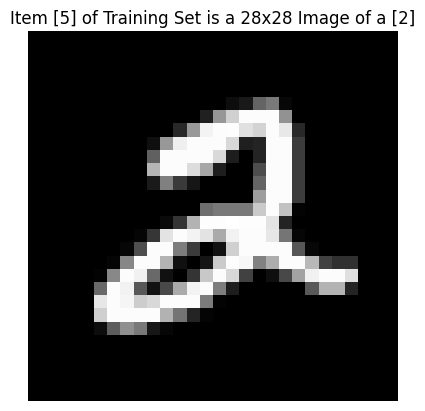

In [6]:
#sample input
#plotting done by gemini
item = 5
image_data = x_train[item].reshape(28, 28) # Reshape to 28x28 for display
plt.imshow(image_data, cmap='gray') # Display the image in grayscale
plt.title(f"Item [{item}] of Training Set is a 28x28 Image of a {np.where(y_train[item] == 1)[0]}")
plt.axis('off') # Hide axes
plt.show()

In [7]:
y_train.shape, x_train.shape

((60000, 10), (60000, 784))

In [8]:
y_val.shape, x_val.shape

((10000, 10), (10000, 784))

---
##Old Model

In [ ]:
nreg_model = Model([Dense(3,784,512,512,activ="relu",f_activ="relu"),Dense(1,512,256,10,f_activ="softmax")])
nreg_model.train(150, x_train[:10000],y_train[:10000],x_val[:500],y_val[:500],val_run=5, l_rate=0.01, batch_size=128)

epoch: 0 	 loss: 2.371102127823294
epoch: 5 	 loss: 0.511669699358444
epoch: 10 	 loss: 0.38415789363742203
epoch: 15 	 loss: 0.3156146698116023
epoch: 20 	 loss: 0.28415191900295284
epoch: 25 	 loss: 0.26663750721779717
epoch: 30 	 loss: 0.2504513117681128
epoch: 35 	 loss: 0.23516814886695184
epoch: 40 	 loss: 0.22544544782379303
epoch: 45 	 loss: 0.2190514926705684
epoch: 50 	 loss: 0.21446672017829976
epoch: 55 	 loss: 0.21428542919281557
epoch: 60 	 loss: 0.19727756342422156
epoch: 65 	 loss: 0.19152892574584637
epoch: 70 	 loss: 0.18559046117740582
epoch: 75 	 loss: 0.18614663613284693
epoch: 80 	 loss: 0.18323988319396375
epoch: 85 	 loss: 0.18042020376102985
epoch: 90 	 loss: 0.1769273139996368
epoch: 95 	 loss: 0.18536012464583745
epoch: 100 	 loss: 0.17167724966115755
epoch: 105 	 loss: 0.16962138762952056
epoch: 110 	 loss: 0.17759203204865612
epoch: 115 	 loss: 0.1674447759253157
epoch: 120 	 loss: 0.17201532204139777
epoch: 125 	 loss: 0.16678064056854644
epoch: 130 	 loss

In [ ]:
saved_nreg = getModelSave(nreg_model)

In [9]:
import json
from google.colab import files

def save(to_save, file_name):
  # Save the model parameters to a JSON file
  with open(file_name, 'w') as f:
      json.dump(to_save, f, indent=4)
  print(f"Model parameters saved to '{file_name}'")

  #download to personal computer to save
  files.download(file_name)

In [ ]:
save(saved_nreg, "base_model_parameters")

NameError: name 'Download' is not defined

In [10]:
!git clone "https://github.com/rylan-berry/DeepLearningIndependentStudy/"

Cloning into 'DeepLearningIndependentStudy'...
remote: Enumerating objects: 796, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 796 (delta 12), reused 7 (delta 2), pack-reused 762 (from 1)
Receiving objects: 100% (796/796), 12.66 MiB | 20.32 MiB/s, done.
Resolving deltas: 100% (437/437), done.
Filtering content: 100% (3/3), 152.02 MiB | 4.77 MiB/s, done.


In [11]:
def Load(file_name):
  # Load the model parameters back from the JSON file
  file_name = f"DeepLearningIndependentStudy/{file_name}"
  with open(file_name, 'r') as f:
      loaded= json.load(f)
  print(f"Model parameters loaded from '{file_name}'")
  return loaded

In [12]:
loaded_nreg = Load("base_model_parameters.json")

Model parameters loaded from 'DeepLearningIndependentStudy/base_model_parameters.json'


In [13]:
new_nreg_model = Model([Dense(3,784,512,512,activ="relu",f_activ="relu"),Dense(1,512,256,10,f_activ="softmax")])
modelLoadParams(loaded_nreg, new_nreg_model)

In [14]:
new_nreg_model(x_train[5]).vals

array([[3.59545573e-05, 1.81062835e-06, 9.80411432e-01, 7.46096522e-05,
        1.09712119e-07, 1.85859935e-06, 3.20744683e-07, 6.35887167e-06,
        1.34971925e-02, 5.97035312e-03]])

In [15]:
a = [int(n+0.5) for n in new_nreg_model(x_train[5]).vals[0]] #it's int + 0.5 to round it
a.index(1) #decodes the one hot array

2

In [ ]:
#l2do_model = Model([Dense(3,784,512,512,activ="relu",f_activ="relu"),Dropout(512,0.4),Dense(1,512,256,10,f_activ="softmax")],pen_fn=l2_reg)
#l2do_model.train(150, x_train[:10000],y_train[:10000],x_val[:500],y_val[:500],val_run=5, l_rate=0.01, _lambda=0.001, batch_size=128)
#Currently breaks due to the changes to dense, it no longer returns a easy `weights, bias` but does it in the form of 'weights, bias, weights, bias...`. Either fix norms or just use a basic model to compare. I'd say leave this for last instead of worrying about it now.

---
##Baseline CNN

This first version will use a small portion of the data to speed up compute times.

In [ ]:

#Not native reshape class but function is there
#class Reshape:
#  def __init__(self, shape):
#    self.shape = shape
#  def __call__(self, x):
#    out = x.reshape(self.shape)
#    return out


In [16]:
x_tr = np.array(x_train)
x1 = x_tr.reshape((-1,28,28))
x1.shape

(60000, 28, 28)

In [18]:
# Using a smaller scale for initialization to keep initial outputs near zero
def xavier_init(size):
    return np.random.randn(*size) * 0.01

cnn0_model = Model([
    Reshape((-1,28,28)),
    Convo2D(xavier_init((5,5))),
    AvgPooling((5,5)),
    Convo2D(xavier_init((5,5))),
    AvgPooling((5,5)),
    Reshape((-1,144)),
    Dense(4, 144, 128, 10, activ="relu", f_activ="softmax")
])

In [19]:
y1 = cnn0_model(x1[:100]).vals
y1.shape

(100, 10)

In [ ]:
import sys
sys.setrecursionlimit(2000)
# Significantly lowered learning rate to ensure stability
cnn0_model.train(100, x_train[:1024], y_train[:1024], x_val[:256], y_val[:256], val_run=5, l_rate=0.00001, batch_size=32)

epoch: 0 	 loss: 3.0617259839716224
ep1: b13/32

In [ ]:
save(getModelSave(cnn0_model))